# Проект модуля. Нейросеть для предсказания калорийности блюд

In [134]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error as MSE
from sklearn.metrics import mean_absolute_error as MAE
from sklearn.metrics import r2_score as R2

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# Метаданные

## флаги отладки

## глобальные параметры

In [135]:
# файловая структура проекта
dataset_dir = os.path.join('.','data','project')

# переметры обучения
target_mae = 50

# Этап 1. EDA исходного датасета 

## `images` - папки с фото блюд

In [136]:
dish_list = os.listdir(os.path.join(dataset_dir,'images'))

print('FYI: всего папок с фото блюд', len(dish_list), ', примеры названий папок:\n', dish_list[:5])

FYI: всего папок с фото блюд 3490 , примеры названий папок:
 ['dish_1556572657', 'dish_1556573514', 'dish_1556575014', 'dish_1556575083', 'dish_1556575124']


## `dish.csv` - список блюд

In [137]:
# сразу зафиксируем порядок записей в таблице блюд (в том числе, удобным для train-test-split образом):
dish_df = pd.read_csv(os.path.join(dataset_dir,'dish.csv')).sort_values(['split','dish_id']).reset_index(drop=True)

dish_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3262 entries, 0 to 3261
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   dish_id         3262 non-null   object 
 1   total_calories  3262 non-null   float64
 2   total_mass      3262 non-null   float64
 3   ingredients     3262 non-null   object 
 4   split           3262 non-null   object 
dtypes: float64(2), object(3)
memory usage: 127.5+ KB


**НАБЛЮДЕНИЕ:** записей меньше, чем папок

In [138]:
dish_df.sample(5, axis=0)

,dish_id,total_calories,total_mass,ingredients,split
2344,dish_1563566725,241.313019,206.0,ingr_0000000161;ingr_0000000012;ingr_000000000...,train
999,dish_1559235639,33.990002,103.0,ingr_0000000002,train
2457,dish_1563984729,495.720032,321.0,ingr_0000000008;ingr_0000000510,train
326,dish_1563566939,286.027252,238.0,ingr_0000000189;ingr_0000000201;ingr_000000000...,test
1916,dish_1562704528,148.903992,56.0,ingr_0000000011,train


**НАБЛЮДЕНИЕ:** значения `dish_id` похожи на именования папок с фото блюд

In [139]:
dish_df.dish_id.value_counts(dropna=False).head()         # проверим уникальность dish_id (все частоты в топе равны 1)

dish_id
dish_1556575327    1
dish_1563294522    1
dish_1563221640    1
dish_1563222745    1
dish_1563222775    1
Name: count, dtype: int64

### а все ли блюда есть в списках и на фото?

In [140]:
counter = 0

for dish in list(dish_df.dish_id):
    if dish not in dish_list:
        counter += 1

if counter == 0:
    print('FYI: All dishes in dish.csv(field "dish_id") are present in dish dir list')
else:
    print('FYI:', counter, 'out of', len(dish_df), 'dishes in dish.csv(field "dish_id") are missing in dish dir list')

counter = 0

for dish in dish_list:
    if dish not in list(dish_df.dish_id):
        counter += 1

if counter == 0:
    print('FYI: All dishes in dish dir list are present in dish.csv(field "dish_id")')
else:
    print('FYI:', counter, 'out of', len(dish_list), 'dishes in dish dir list are missing in dish.csv(field "dish_id")')

FYI: All dishes in dish.csv(field "dish_id") are present in dish dir list
FYI: 228 out of 3490 dishes in dish dir list are missing in dish.csv(field "dish_id")


In [141]:
len(dish_df) + counter,  len(dish_list)     # проверяем возможные причины - должны совпасть!

(3490, 3490)

**ВЫВОДЫ:**
* 228 папок с фото лишние в датасете - для них нет информации в списке блюд
* для всех блюд в списке есть папка с фото (поэтому лишние фото не помешают строить детесет, исходя из списка блюд)

## `ingredients.csv` - список ингредиентов

In [142]:
ingr_df = pd.read_csv(os.path.join(dataset_dir,'ingredients.csv')).sort_values('id').reset_index(drop=True)

ingr_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 555 entries, 0 to 554
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      555 non-null    int64 
 1   ingr    555 non-null    object
dtypes: int64(1), object(1)
memory usage: 8.8+ KB


In [143]:
ingr_df.head()

,id,ingr
0,1,cottage cheese
1,2,strawberries
2,3,garden salad
3,4,bacon
4,5,potatoes


In [144]:
ingr_df.id.value_counts(dropna=False).head()                 # проверим уникальность id (все частоты в топе равны 1)

id
1      1
373    1
367    1
368    1
369    1
Name: count, dtype: int64

### ID ингредиентов имеют разный формат в двух таблицах, проверим предполагаемое мнемоническое правило:
если в поле `ingredients` списка блюд отбросить все знаки левее первой отличной от нуля цифры, то получим целый ID из `indredients.csv` колонка `id`

In [145]:
dish_df['dish_ingr_list'] = dish_df.ingredients.map(lambda s: s.strip().split(';'))   # конвертим строку в список

In [146]:
dish_df.dish_ingr_list = dish_df.dish_ingr_list.map(pd.Series).map(                       # конвертим список в серию пандас
                            lambda ser: ser.map(                                          # к каждой серии применяем map()
                                lambda s: int(re.sub(r"^0+", "", re.sub(r"\D", "", s)))   # с регулярным выражением и 
                            )                                                             # конвертим остаток в целый тип
                        ).map(list)                                                       # возвращаем тип список (целых)

**NB!:** теперь предполагается, что поле `dish_ingr_list` содержит списки целочисленных ID ингредиентов из таблицы таковых (поле `id`)

In [147]:
dish_df.sample(5, axis=0)

,dish_id,total_calories,total_mass,ingredients,split,dish_ingr_list
1976,dish_1562790295,538.709778,268.0,ingr_0000000124;ingr_0000000291;ingr_000000012...,train,"[124, 291, 126, 105, 201, 161, 515, 517, 189, ..."
2246,dish_1563391922,24.440001,104.0,ingr_0000000027;ingr_0000000021;ingr_0000000485,train,"[27, 21, 485]"
3153,dish_1567785165,273.112488,116.0,ingr_0000000029;ingr_0000000041;ingr_000000004...,train,"[29, 41, 40, 39, 338, 294]"
2958,dish_1566416421,313.741882,367.0,ingr_0000000514;ingr_0000000520;ingr_000000004...,train,"[514, 520, 43, 517, 49, 471, 122, 433, 133, 52..."
2864,dish_1565898511,57.160000,102.0,ingr_0000000471;ingr_0000000012,train,"[471, 12]"


### все ли ингрединенты из таблицы ингредиентов используются при приготовлении блюд из списка блюд?

In [148]:
ingr_list = list(set(dish_df.dish_ingr_list.sum()))

len(ingr_list)

200

**НАБЛЮДЕНИЕ:** уже точно видно, что используются не все - в списке блюд менее половины ингредиентов (по количеству) из таблицы последних

In [149]:
counter = 0

for ingr in ingr_list:
    if ingr not in list(ingr_df.id):
        counter += 1

if counter == 0:
    print('FYI: All ingrs in dish used ingr list are present in ingredients.csv(field "id")')
else:
    print('FYI:', counter, 'out of', len(ingr_list), 
          'ingrs in dish used ingr list are missing in ingredients.csv(field "id")')
    
counter = 0

for ingr in list(ingr_df.id):
    if ingr not in ingr_list:
        counter += 1

if counter == 0:
    print('FYI: All ingrs in ingredients.csv(field "id") are present in dish used ingr list')
else:
    print('FYI:', counter, 'out of', len(ingr_df), 
          'ingrs in ingredients.csv(field "id") are missing in dish used ingr list')

FYI: All ingrs in dish used ingr list are present in ingredients.csv(field "id")
FYI: 355 out of 555 ingrs in ingredients.csv(field "id") are missing in dish used ingr list


In [150]:
len(ingr_df),  len(ingr_list) + counter     # проверяем возможные причины - должны совпасть!

(555, 555)

**ВЫВОДЫ:**
* 355 ингредиентов являются лишними степенями свободы для векторизации состава блюд в датасете - их лучше удалить
* для всех ингредиентов, использованных в списке блюд есть запись в таблице ингредиентов с текстовым полем названия

In [151]:
ingr_df = ingr_df.query('id in @ingr_list').reset_index(drop=True)

ingr_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      200 non-null    int64 
 1   ingr    200 non-null    object
dtypes: int64(1), object(1)
memory usage: 3.2+ KB


### далее можно добавить всю информацию в таблицу блюд и более уже не возвращаться к таблице ингредиентов

#### векторизация блюд по используемым ингредиентам

In [152]:
V_ingr_ij = np.array(
    [
        [ int(i in dish_df.dish_ingr_list[j]) for i in list(ingr_df.id) ]
        for j in range(len(dish_df))
    ]
)

V_ingr_ij.shape

(3262, 200)

собственно, вливать эту numpy-матрицу в панда-датасет нет необходимости, так как использовать его можно напрямую.  Важно лишь что между `dish_df` и `V_ingr_ij` есть соответствие по первому индексу, которое всегда можно восстановить:

In [153]:
dish_df[['dish_id', 'split']].join(pd.DataFrame(V_ingr_ij)).sample(10, axis=0)

,dish_id,split,0,1,2,3,4,5,6,7,...,190,191,192,193,194,195,196,197,198,199
1791,dish_1562184604,train,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3140,dish_1567613019,train,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1978,dish_1562859116,train,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1948,dish_1562784347,train,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2899,dish_1566317742,train,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1880,dish_1562691466,train,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
2475,dish_1564073641,train,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
853,dish_1558641358,train,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
2021,dish_1562874203,train,0,0,0,0,0,0,0,0,...,0,0,1,1,0,0,0,0,0,0
48,dish_1558376306,test,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


матрица `V_ingr_ij` достаточно спарсная, но ее размеры не мешают хранить ее в плотном виде (имея ввиду дополнить ее другими неспарсными полями при моделировании)

In [154]:
print('FYI: степень заполненности матрицы векторизации блюд по ингредиентам =', 
      round(V_ingr_ij.sum() / V_ingr_ij.shape[0] / V_ingr_ij.shape[1] *100, 2), '%')

FYI: степень заполненности матрицы векторизации блюд по ингредиентам = 3.66 %


#### текстовое описание состава блюд

In [155]:
dish_df['descr'] = dish_df.dish_ingr_list.map(lambda lst:
                    ' '.join([ ingr_df.query('id == @n').iloc[0,1] for n in lst ])
                     )

In [156]:
dish_df.drop(columns=['ingredients']).sample(10, axis=0)

,dish_id,total_calories,total_mass,split,dish_ingr_list,descr
514,dish_1556575446,103.299995,152.0,train,"[12, 16, 34]",olives brussels sprouts celery
2664,dish_1565107171,501.884644,724.0,train,"[437, 8, 161, 128, 121, 440]",sweet potato scrambled eggs olive oil egg whit...
2742,dish_1565627800,167.189270,261.0,train,"[437, 161, 128]",sweet potato olive oil egg whites
1685,dish_1562007789,302.954895,322.0,train,"[122, 6, 133, 16, 518, 161, 520, 524, 312, 515...",garlic caesar salad shallots brussels sprouts ...
2667,dish_1565109637,172.644882,253.0,train,"[437, 161, 128]",sweet potato olive oil egg whites
2999,dish_1566588066,566.233398,562.0,train,"[45, 38, 291, 518, 161, 515, 23, 312, 332]",carrot pineapple salt thyme olive oil arugula ...
1838,dish_1562614895,51.799999,148.0,train,[27],broccoli
1666,dish_1561752563,373.507965,367.0,train,"[52, 342, 6, 312, 522, 94, 31, 72, 203, 520, 1...",cheese turnips caesar salad pepper tatsoi onio...
1533,dish_1561577701,258.637756,263.0,train,"[161, 94, 291, 133, 511, 7, 525, 513, 25, 189]",olive oil onions salt shallots spinach (cooked...
705,dish_1558547008,73.919998,96.0,train,[5],potatoes


## статистика полей датасета блюд

### train-test split

In [157]:
pd.DataFrame(
    [dish_df.split.value_counts(dropna=False), dish_df.split.value_counts(dropna=False, normalize=True)*100]
).T.map(round)

,count,proportion
split,,
train,2755,84
test,507,16


### блюда с нулевым составом

In [158]:
pd.DataFrame(
    index=['calories > 0','mass > 0'],
    data=[
        dish_df.total_calories.map(lambda d: d > 0).value_counts(dropna=False),
        dish_df.total_mass.map(lambda d: d > 0).value_counts(dropna=False)
    ]
).T

,calories > 0,mass > 0
True,3260.0,3262.0
False,2.0,NaN


### посмотрим на веса и калорийность блюд в датасете

C:\Users\aseva\AppData\Local\Temp\ipykernel_7552\2068803698.py:5: RuntimeWarning: divide by zero encountered in log
  axes[1].hist(dish_df.total_calories.map(lambda d: np.log(d)/np.log(10.0)), bins=[-1 + 0.05*i for i in range(101)])


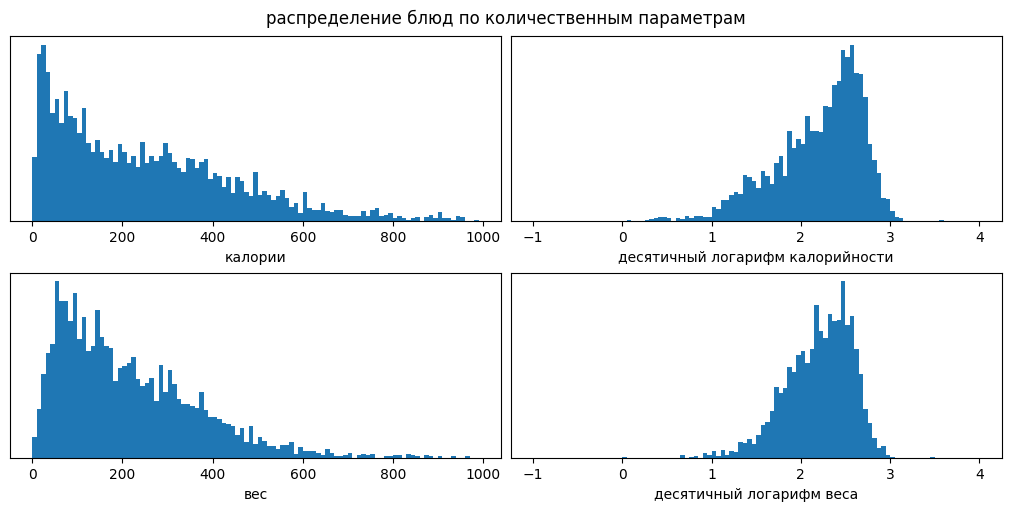

In [159]:
fig, axes = plt.subplots(2,2, figsize=(10,5), layout='constrained')
axes = axes.flatten()

axes[0].hist(dish_df.total_calories, bins=range(0,1000,10))
axes[1].hist(dish_df.total_calories.map(lambda d: np.log(d)/np.log(10.0)), bins=[-1 + 0.05*i for i in range(101)])

axes[2].hist(dish_df.total_mass, bins=range(0,1000,10))
axes[3].hist(dish_df.total_mass.map(lambda d: np.log(d)/np.log(10.0)), bins=[-1 + 0.05*i for i in range(101)])

for i in range(4): axes[i].set_yticks([])
axes[0].set_xlabel('калории')
axes[2].set_xlabel('вес')
axes[1].set_xlabel('десятичный логарифм калорийности')
axes[3].set_xlabel('десятичный логарифм веса')

fig.suptitle('распределение блюд по количественным параметрам')
plt.show()

**ВЫВОДЫ ИЗ ГРАФИКОВ:**
* распределения ближе к логнормальным
* однако спешить переходить к логарифмам не стоит, так как в природе самих параметров заложена аддитивность по отношению к целевой переменной, а не мультипликативность. Поэтому есть надежда сделать более точный baseline на аддитивных параметрах

### посмотрим на частотность ингредиентов в блюдах

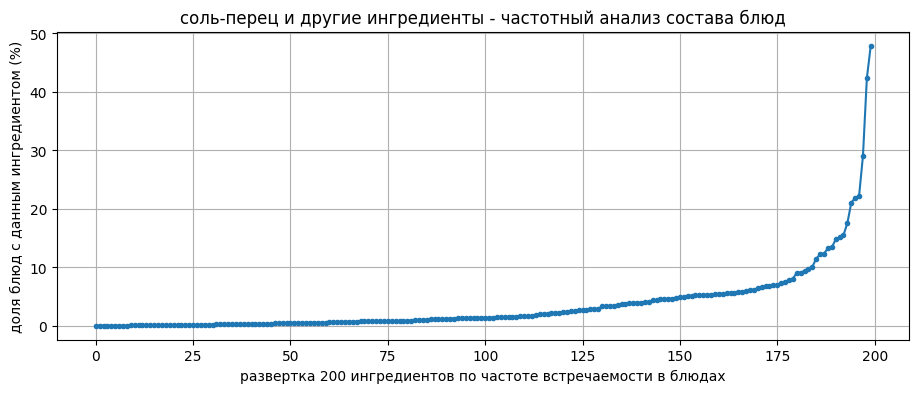

In [160]:
y = np.sort(V_ingr_ij.sum(axis=0)/len(dish_df)*100)    # делаем развертку по частоте
plt.figure(figsize=(11,4))
plt.plot(y, marker='.')
plt.ylabel('доля блюд с данным ингредиентом (%)')
plt.xlabel('развертка 200 ингредиентов по частоте встречаемости в блюдах')
plt.title('соль-перец и другие ингредиенты - частотный анализ состава блюд')
plt.grid()
plt.show()

**ВЫВОДЫ ИЗ ГРАФИКОВ:**
как видим, компоненты вектора разномасштабные - не забыть про нормализацию!

# Baseline models

In [161]:
baseline = {}

## готовим данные

In [162]:
Xy = np.concatenate([dish_df[['total_calories','total_mass']].values, V_ingr_ij], axis=1)

Xy.shape

(3262, 202)

In [163]:
y = Xy[:,0]
X = Xy[:,1:]

X.shape, y.shape

((3262, 201), (3262,))

### нормализуем только предикторы

In [164]:
scaler = StandardScaler()

X_norm = scaler.fit_transform(X)

In [165]:

X.mean(axis=0).std(), X_norm.mean(axis=0).std()         # должно обнулиться

(15.123308572807513, 1.5035966975073705e-15)

In [166]:
X.std(axis=0)[:10], X_norm.std(axis=0)[:10]             # должно стать единицами

(array([1.61472671e+02, 6.05408267e-02, 1.38690036e-01, 5.52829630e-02,
        2.34208930e-01, 1.20409180e-01, 2.31294686e-01, 2.62075968e-01,
        2.34786237e-01, 6.76554547e-02]),
 array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]))

### разделяем трейн и тест выборки

In [167]:
X_test = X_norm[:(dish_df.split == 'test').sum()]        # мы сразу упорядочили dish_df по полю split
X_train = X_norm[(dish_df.split == 'test').sum():]

y_test = y[:(dish_df.split == 'test').sum()]
y_train = y[(dish_df.split == 'test').sum():]


X_train.shape, y_train.shape, X_test.shape, y_test.shape

((2755, 201), (2755,), (507, 201), (507,))

## линейная регрессия - Least Square Plane

In [168]:
baseline['linear'] = LinearRegression()
baseline['linear'].fit(X_train,y_train)
y_pred = baseline['linear'].predict(X_test)

print('Baseline model LR results on test data:')
print('MAE =', round(MAE(y_test, y_pred),2), 'калорий')
print('RMSE =', round(np.sqrt(MSE(y_test, y_pred)),2), 'калорий')
print('R2 =', round(R2(y_test, y_pred)*100,2), '%')

Baseline model LR results on test data:
MAE = 56.45 калорий
RMSE = 89.1 калорий
R2 = 82.34 %


**ВЫВОДЫ:**
* хоть мы значительно не дотягиваем до целевого MAE (50), линейная регрессия, как обычно, хороша интерпретацией результата: по факту, она дает нам в своих весах рецепты блюд - если нормировать их на суммарную калорийность total_calories, то веса прямо дадут нам ответ, сколько взять каждого ингредиента в калориях
* обычно мы измеряем ингредиенты в граммах - если взять за целевую переменную total_mass, то веса дадут количества ингредиентов в граммах

## ансамбли решающих деревьев - Histogram-based Gradient Boosting Regression Tree

In [169]:
baseline['HGBoost'] = HistGradientBoostingRegressor()
baseline['HGBoost'].fit(X_train,y_train)
y_pred = baseline['HGBoost'].predict(X_test)

print('Baseline model HGB results on test data:')
print('MAE =', round(MAE(y_test, y_pred),2), 'калорий')
print('RMSE =', round(np.sqrt(MSE(y_test, y_pred)),2), 'калорий')
print('R2 =', round(R2(y_test, y_pred)*100,2), '%')

Baseline model HGB results on test data:
MAE = 51.73 калорий
RMSE = 88.56 калорий
R2 = 82.56 %


**ВЫВОДЫ:**
* мы почти достигли целевого MAE (50) - без DL и без генерации DL-фич !
* фокус в том, что состав блюд по ингредиентам и вес - это уже сами по себе релевантные фичи для задачи калорийности
* более того, наша векторизация по id ингредиентов, по факту, является наиболее релевантной задаче семантической токинезацией текстового описания - вряд ли вектор с токинезаций и эмбеддингом по общеязыковому Word2Vec алгоритму будет более имманентен задаче.  Едиственно, что может добавить Word2Vec fkujhbnv к нашей векторизации по ингредиентам, - это учесть синонимы одного и того же ингредиента с близкой калорийностью - например, говядина и телятина, или курица и цыпленок, или булочка и хлеб, ну или сыграть на семантической аддитивности Word2Vec-векторов: типа, сэндвич коллинеарен (хлеб + ветчина + сыр).
* маловероятно, что DL-фичи, экстрактированные предобученными моделями из фото или текстового описания ингредиентов блюд, будут более релевантными задаче, чем уже использованные,  - в лучшем случае они добавят чуть больше дополнительной точности, чем привнесут шума!
* но мне уже просто интересно, сколько по-максимуму можно выжать из табличных фич и ингредиентной векторизации - поэтому попробуем еще один бейслайн - полносвязную нейронку с механизмами борьбы с переобучением на коротком датасете:  

## полносвязная нейронная сеть для регрессии - MLP regressor

### собираем загрузчик данных

In [170]:
train_dataset = TensorDataset(torch.tensor(X_train, dtype=torch.float32), 
                              torch.tensor(y_train, dtype=torch.float32).unsqueeze(1))
test_dataset = TensorDataset(torch.tensor(X_test, dtype=torch.float32), 
                             torch.tensor(y_test, dtype=torch.float32).unsqueeze(1))

In [171]:
train_loader = DataLoader( train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader( test_dataset, batch_size=32, shuffle=False)

### собираем архитектуру сети

In [172]:
input_size = X_train.shape[1]

model = nn.Sequential(
    nn.Linear(input_size, 256),
    nn.BatchNorm1d(256),
    nn.ReLU(),

    nn.Linear(256, 64),
    nn.BatchNorm1d(64),
    nn.ReLU(),
    nn.Dropout(p=0.1),

    nn.Linear(64, 1)
)

### функцию потерь берем по метрике, по которой задан порог обучения

In [173]:

criterion = nn.L1Loss()                  # MAE

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

### цикл обучения минибатчами

In [174]:
epochs_history = []
nof_epochs = 401                            # обучение происходит очень быстро даже на CPU
best_MAE = 250

for epoch in range(nof_epochs):
    running_train_loss = 0.0
    running_val_loss = 0.0

    model.train()
    counter = 0
    for X_batch, y_batch in train_loader:
        
        pred = model(X_batch)
        loss = criterion(pred, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_train_loss += loss
        counter += 1
    
    avg_train_loss = (running_train_loss / counter).item()

    model.eval()
    counter = 0
    for X_batch, y_batch in test_loader:
        
        pred = model(X_batch)
        loss = criterion(pred, y_batch)
        running_val_loss += loss
        counter += 1
    
    avg_val_loss = (running_val_loss / counter).item()

    if best_MAE > avg_val_loss:
        best_MAE = avg_val_loss

    if epoch % 20 == 0:
        epochs_history.append( [epoch, avg_train_loss, avg_val_loss])
        print('Epoch No', str(epoch).rjust(3), 
              ' |  Train MAE =', round(avg_train_loss,2), 
              ' |  Validation MAE =', round(avg_val_loss,2))
        
print('='*70)
print('Best MAE reached =', best_MAE)

Epoch No   0  |  Train MAE = 253.76  |  Validation MAE = 255.05
Epoch No  20  |  Train MAE = 214.74  |  Validation MAE = 215.84
Epoch No  40  |  Train MAE = 121.09  |  Validation MAE = 131.82
Epoch No  60  |  Train MAE = 36.03  |  Validation MAE = 60.57
Epoch No  80  |  Train MAE = 31.28  |  Validation MAE = 50.71
Epoch No 100  |  Train MAE = 27.1  |  Validation MAE = 48.23
Epoch No 120  |  Train MAE = 28.2  |  Validation MAE = 47.61
Epoch No 140  |  Train MAE = 24.7  |  Validation MAE = 47.46
Epoch No 160  |  Train MAE = 24.91  |  Validation MAE = 44.77
Epoch No 180  |  Train MAE = 24.58  |  Validation MAE = 44.7
Epoch No 200  |  Train MAE = 24.45  |  Validation MAE = 44.62
Epoch No 220  |  Train MAE = 25.41  |  Validation MAE = 42.87
Epoch No 240  |  Train MAE = 23.52  |  Validation MAE = 42.11
Epoch No 260  |  Train MAE = 24.21  |  Validation MAE = 43.25
Epoch No 280  |  Train MAE = 24.04  |  Validation MAE = 41.78
Epoch No 300  |  Train MAE = 23.2  |  Validation MAE = 42.99
Epoch N

### визуализация обучения по эпохам

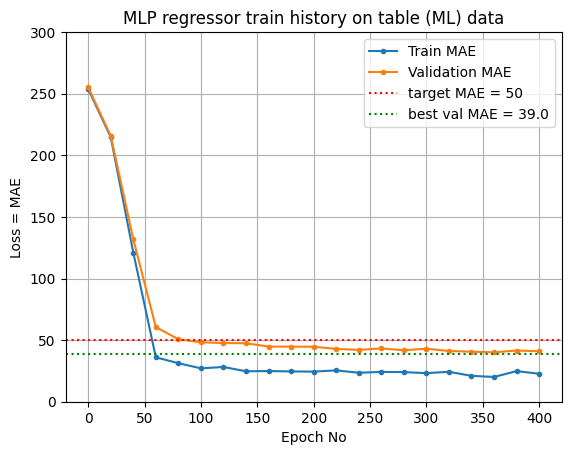

In [176]:
loss_history = np.array(epochs_history)

plt.plot(loss_history[:,0], loss_history[:,1], marker='.', label='Train MAE')
plt.plot(loss_history[:,0], loss_history[:,2], marker='.', label='Validation MAE')
plt.axhline(50, color='red', ls=':', label='target MAE = 50')
plt.axhline(best_MAE, color='green', ls=':', label='best val MAE = '+ str(round(best_MAE,1)))
plt.ylim(0,300)
plt.grid()
plt.legend()
plt.title('MLP regressor train history on table (ML) data')
plt.xlabel('Epoch No')
plt.ylabel('Loss = MAE')
plt.show()

**ВЫВОДЫ ПО BASELINE МОДЕЛЯМ:**
* когнитивные способности одержали верх над комбинаторными - лучшая модель на основе скромного перцептрона с двумя скрытыми слоями и (201 + 1) * 256 + (256 + 1) * 64 + 64 + 1 = 68225 параметрами достигла уровня МАЕ=40 без использования DL-фич, обычным табличным ML:
  * Линейная регрессия MAE = 56+
  * GBoost ансамбли MAE = 51+
  * Полносвязная NN MAE = 41 +/- 1